In [1]:
from pyspark.sql import SparkSession

# Stop any existing ghost sessions just to be safe
try:
    spark.stop()
except:
    pass

# Force the connection to your Spark Master container
spark = SparkSession.builder \
    .appName("MOOC_Distributed_model") \
    .master("spark://spark-master:7077") \
    .config("spark.executor.memory", "2g") \
    .config("spark.executor.cores", "2") \
    .getOrCreate()

# Verify the connection
print(spark.sparkContext.master)

spark://spark-master:7077


In [2]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Load the cleaned Parquet data from HDFS
df = spark.read.parquet("hdfs://namenode:9000/data/mooc/processed/Comments_cleaned.parquet")



In [3]:
df.show()

+----+-------------------+--------------------+---------+-----------------+--------------------+--------------------+
|rate|               date|             comment|sentiment|detected_language|  translated_comment|          clean_text|
+----+-------------------+--------------------+---------+-----------------+--------------------+--------------------+
| 3.0|2020-04-25 15:58:55|Very good explana...|  neutral|               en|Very good explana...|very good explana...|
| 3.0|2020-07-19 16:45:46|Some Answers are ...|  neutral|               en|Some Answers are ...|answer wrong but ...|
| 3.5|2020-07-22 08:18:00|As a former princ...| positive|               en|As a former princ...|former principal ...|
| 1.0|2020-03-26 22:20:31|no cohesion very ...| negative|               en|no cohesion very ...|no cohesion very ...|
| 1.0|2020-04-23 06:38:27|The instructor do...| negative|               en|The instructor do...|instructor not pr...|
| 1.0|2020-05-26 00:20:56|Terrible, awful, ...| negative

In [4]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Load the cleaned Parquet data from HDFS
df = spark.read.parquet("hdfs://namenode:9000/data/mooc/processed/Comments_cleaned.parquet")

# Drop any rows where clean_text might have become null after preprocessing
df = df.dropna(subset=["clean_text"])

# Convert text sentiments to numerical labels (0.0, 1.0, 2.0)
indexer = StringIndexer(inputCol="sentiment", outputCol="label")
df_indexed = indexer.fit(df).transform(df)

# Split the data into training and testing sets
train_data, test_data = df_indexed.randomSplit([0.8, 0.2], seed=42)

# Force Spark to hold the indexed data in the Worker's RAM
train_data.cache()
test_data.cache()

DataFrame[rate: double, date: timestamp, comment: string, sentiment: string, detected_language: string, translated_comment: string, clean_text: string, label: double]

In [5]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# 1. Define the Feature Engineering stages
tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=5000)
idf = IDF(inputCol="rawFeatures", outputCol="features")

# 2. Define the Classifier
lr_tfidf = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)

# 3. Build and Train the Pipeline
pipeline_tfidf = Pipeline(stages=[tokenizer, hashingTF, idf, lr_tfidf])
model_tfidf = pipeline_tfidf.fit(train_data)

# 4. Make Predictions and Evaluate
predictions_tfidf = model_tfidf.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy_tfidf = evaluator.evaluate(predictions_tfidf)

print(f"Distributed TF-IDF Testing Accuracy: {accuracy_tfidf:.4f}")

Distributed TF-IDF Testing Accuracy: 0.0000


In [9]:
from pyspark.ml.feature import Word2Vec

# 1. Define the Word2Vec stage (vectorSize defines the embedding dimensions)
word2Vec = Word2Vec(vectorSize=100, minCount=0, inputCol="words", outputCol="features")

# 2. Define the Classifier
lr_w2v = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)

# 3. Build and Train the Pipeline (reusing the tokenizer from above)
pipeline_w2v = Pipeline(stages=[tokenizer, word2Vec, lr_w2v])
model_w2v = pipeline_w2v.fit(train_data)

# 4. Make Predictions and Evaluate
predictions_w2v = model_w2v.transform(test_data)
accuracy_w2v = evaluator.evaluate(predictions_w2v)

print(f"Distributed Word2Vec Testing Accuracy: {accuracy_w2v:.4f}")

Distributed Word2Vec Testing Accuracy: 0.6667


In [10]:
from pyspark.sql import Row
from pyspark.ml.feature import IndexToString

# Define custom test strings
test_strings = [
    Row(clean_text="i did like it"),
    Row(clean_text="it is not bad but it is not good also"),
    Row(clean_text="did not love it")
]

# Create a DataFrame
df_custom_test = spark.createDataFrame(test_strings)

# Run the DataFrame through the trained TF-IDF model
custom_predictions = model_w2v.transform(df_custom_test)





# 1. Extract the exact label mapping from your original dataset
indexer_model = indexer.fit(df)

# 2. Initialize the inverse converter
converter = IndexToString(
    inputCol="prediction", 
    outputCol="predicted_class", 
    labels=indexer_model.labels # Automatically maps 0.0, 1.0, 2.0 to the correct strings
)

# 3. Transform the numerical predictions back to text
final_custom_predictions = converter.transform(custom_predictions)

# 4. Display the final readable results
final_custom_predictions.select("clean_text", "prediction", "predicted_class").show(truncate=False)

+-------------------------------------+----------+---------------+
|clean_text                           |prediction|predicted_class|
+-------------------------------------+----------+---------------+
|i did like it                        |2.0       |negative       |
|it is not bad but it is not good also|0.0       |neutral        |
|did not love it                      |2.0       |negative       |
+-------------------------------------+----------+---------------+



 EVALUATING: TF-IDF + Logistic Regression

Cluster-Calculated Accuracy : 0.0000
Cluster-Calculated F1-Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       0.0
    positive       0.00      0.00      0.00       2.0
    negative       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



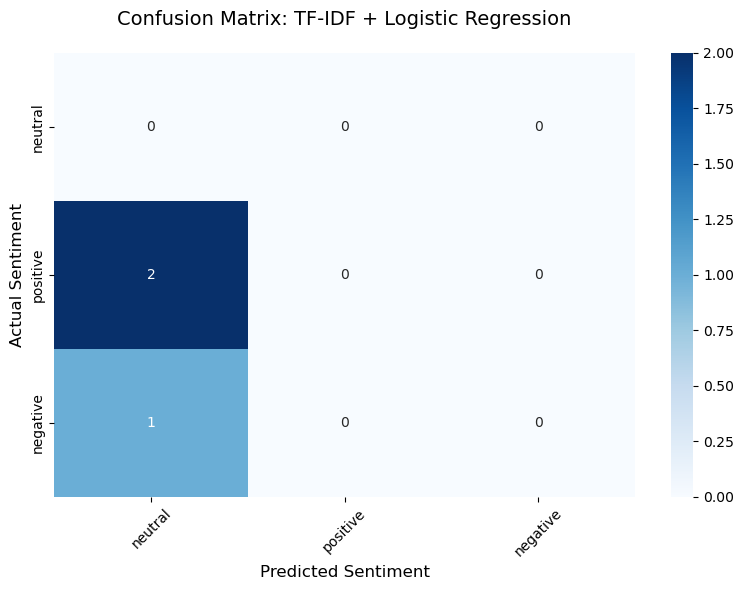

 EVALUATING: Word2Vec + Logistic Regression

Cluster-Calculated Accuracy : 0.6667
Cluster-Calculated F1-Score : 0.6667

Classification Report:
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00         0
    positive       1.00      0.50      0.67         2
    negative       0.50      1.00      0.67         1

   micro avg       0.67      0.67      0.67         3
   macro avg       0.50      0.50      0.44         3
weighted avg       0.83      0.67      0.67         3



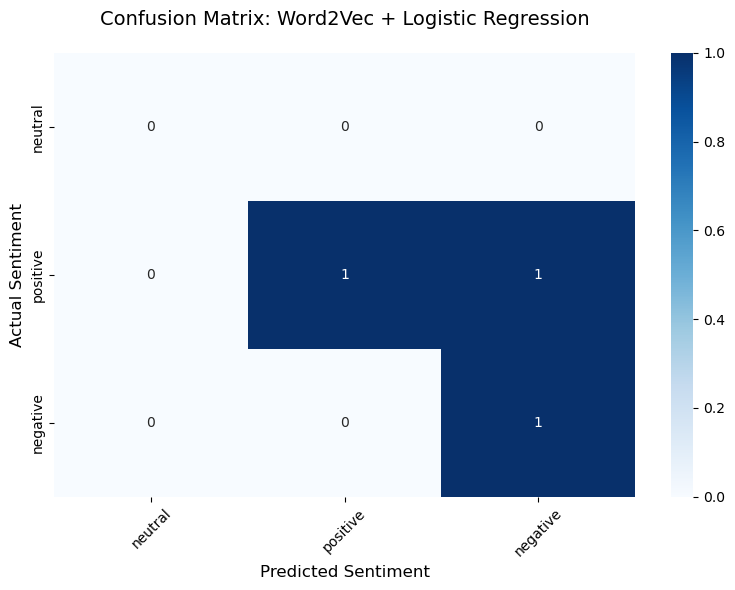

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report, confusion_matrix

# Extract the actual string labels from the fitted Indexer model to label our charts
label_names = indexer_model.labels

def evaluate_spark_model(predictions_df, model_name):
    print(f"{'='*50}")
    print(f" EVALUATING: {model_name}")
    print(f"{'='*50}\n")
    
    # 1. Distributed Evaluation (Spark Native)
    evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    accuracy = evaluator.evaluate(predictions_df, {evaluator.metricName: "accuracy"})
    f1 = evaluator.evaluate(predictions_df, {evaluator.metricName: "f1"})
    
    print(f"Cluster-Calculated Accuracy : {accuracy:.4f}")
    print(f"Cluster-Calculated F1-Score : {f1:.4f}\n")
    
    # 2. Safely collect predictions as standard Python objects
    collected_rows = predictions_df.select("label", "prediction").collect()
    
    y_true = [row['label'] for row in collected_rows]
    y_pred = [row['prediction'] for row in collected_rows]
    
    # Create the explicit numeric labels list [0.0, 1.0, 2.0] to match label_names
    expected_labels = [float(i) for i in range(len(label_names))]
    
    # 3. Generate Classification Report (force the labels array to prevent mismatch)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, 
                                labels=expected_labels, 
                                target_names=label_names, 
                                zero_division=0))
    
    # 4. Generate and Plot the Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=expected_labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_names, yticklabels=label_names)
    
    plt.title(f'Confusion Matrix: {model_name}', pad=20, fontsize=14)
    plt.xlabel('Predicted Sentiment', fontsize=12)
    plt.ylabel('Actual Sentiment', fontsize=12)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Execute the evaluation for both pipelines
evaluate_spark_model(predictions_tfidf, "TF-IDF + Logistic Regression")
evaluate_spark_model(predictions_w2v, "Word2Vec + Logistic Regression")

Training CrossValidator... This will take a few minutes.
Best Model Selected!
 EVALUATING: Optimized TF-IDF Pipeline

Cluster-Calculated Accuracy : 0.0000
Cluster-Calculated F1-Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

     neutral       0.00      0.00      0.00       0.0
    positive       0.00      0.00      0.00       2.0
    negative       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



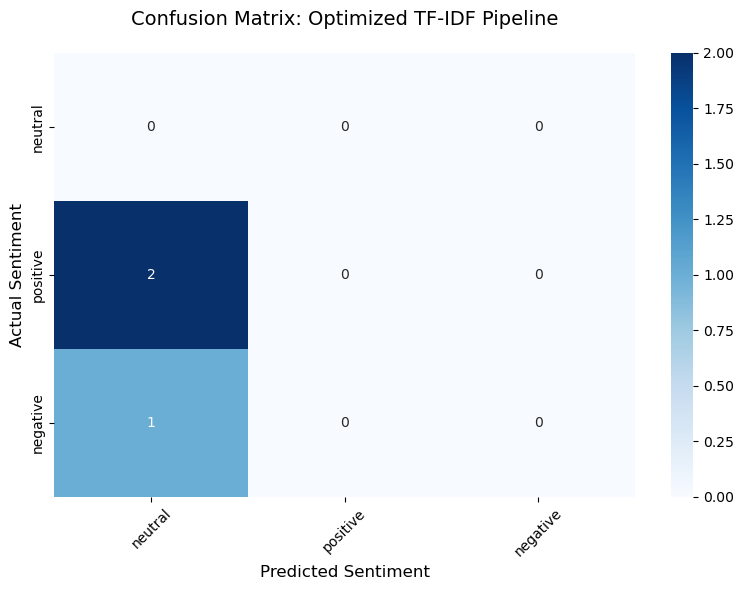

In [13]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# 1. Create a grid of parameters to test
# testing different regularization strengths (regParam) and ElasticNet mixing (elasticNetParam)
paramGrid = ParamGridBuilder() \
    .addGrid(lr_tfidf.regParam, [0.1, 0.01]) \
    .addGrid(lr_tfidf.elasticNetParam, [0.0, 0.5]) \
    .build()

# 2. Define the CrossValidator (using 3 folds to save time)
crossval = CrossValidator(estimator=pipeline_tfidf,
                          estimatorParamMaps=paramGrid,
                          evaluator=MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1"),
                          numFolds=3)

# 3. Train to find the best model
print("Training CrossValidator... This will take a few minutes.")
cv_model = crossval.fit(train_data)

# 4. Extract the best model and evaluate
best_model = cv_model.bestModel
cv_predictions = best_model.transform(test_data)

print("Best Model Selected!")
evaluate_spark_model(cv_predictions, "Optimized TF-IDF Pipeline")

In [14]:
# # Save the fitted pipeline to HDFS
# model_path = "hdfs://namenode:9000/data/mooc/models/best_sentiment_pipeline"

# # Use overwrite to avoid errors if you run the cell twice
# best_model.write().overwrite().save(model_path)

# print(f"Model successfully saved to HDFS at: {model_path}")
